# 02: Comparaison de prompts (baseline vs improved)

> **Prototype pédagogique. Non destiné au diagnostic.**

**Objectif (niveau Should).** Comparer les deux versions du système sur le **même** jeu RSNA :
- **baseline** : `prompts/baseline_prompt.txt`, sans règle d'incertitude ;
- **improved** : `prompts/improved_prompt.txt` + bascule `uncertain` si confiance < 0.60.

Ce notebook **ne fait aucune inférence** : il lit les résultats déjà calculés dans `eval/results/` (donc **aucun GPU requis**, il tourne partout, y compris sur CPU). Les résultats sont produits par :

```bash
python eval/run_evaluation.py --engine medgemma --mode baseline --cases data/rsna_cases.csv --out-dir eval/results
python eval/run_evaluation.py --engine medgemma --mode improved --cases data/rsna_cases.csv --out-dir eval/results
```

> ⚠️ **Reproductibilité.** Les chiffres ci-dessous reflètent la version des prompts **au moment où l'évaluation a été lancée**. Si vous modifiez `prompts/improved_prompt.txt`, relancez l'évaluation `--mode improved` avant de conclure, sinon le tableau compare l'ancien prompt.

In [1]:
import sys, json
from pathlib import Path

# Racine du dépôt, quel que soit le dossier de lancement du kernel.
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src').is_dir() and (candidate / 'prompts').is_dir():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
RES = ROOT / 'eval' / 'results'

# Ce notebook LIT des résultats déjà calculés (aucune inférence, aucun GPU requis).
_needed = ['before_after_summary.csv', 'baseline_predictions.csv', 'improved_predictions.csv']
_missing = [f for f in _needed if not (RES / f).exists()]
if _missing:
    print('ATTENTION : fichiers manquants dans eval/results/ :', _missing)
    print('Generez-les avant de continuer :')
    print('  python eval/run_evaluation.py --engine medgemma --mode baseline --cases data/rsna_cases.csv --out-dir eval/results')
    print('  python eval/run_evaluation.py --engine medgemma --mode improved --cases data/rsna_cases.csv --out-dir eval/results')
else:
    print('Resultats trouves dans', RES.relative_to(ROOT))

Resultats trouves dans eval\results


## Tableau de synthèse baseline vs improved

In [2]:
summary = pd.read_csv(RES / 'before_after_summary.csv')
summary[['mode', 'accuracy', 'macro_f1', 'sensitivity', 'specificity',
         'json_valid_rate', 'uncertain_rate', 'hallucination_rate']]

,mode,accuracy,macro_f1,sensitivity,specificity,json_valid_rate,uncertain_rate,hallucination_rate
0,baseline,0.9333,0.6437,0.9333,0.9333,1.0,0.0667,0.0
1,improved,0.8333,0.5792,0.6667,1.0000,1.0,0.1000,0.0


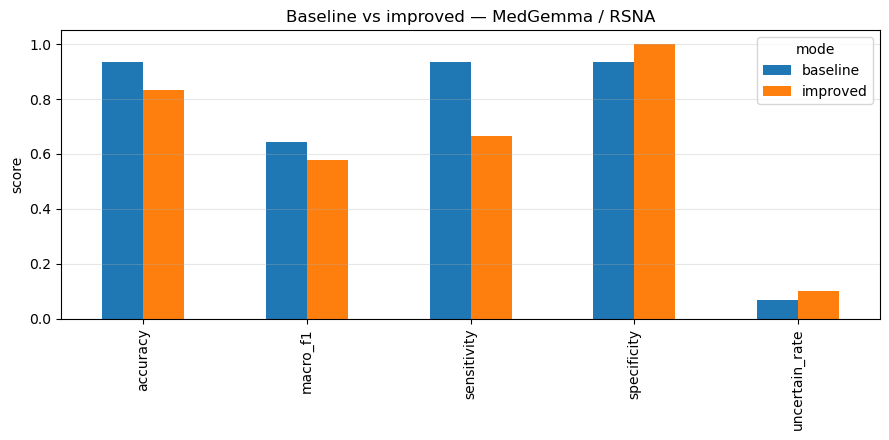

In [3]:
# Barres comparatives
metrics = ['accuracy', 'macro_f1', 'sensitivity', 'specificity', 'uncertain_rate']
ax = summary.set_index('mode')[metrics].T.plot.bar(figsize=(9, 4.5))
ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_title('Baseline vs improved: MedGemma / RSNA')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()

## Où les deux versions divergent

In [4]:
base = pd.read_csv(RES / 'baseline_predictions.csv')[['case_id', 'label', 'predicted_class', 'confidence']]
imp = pd.read_csv(RES / 'improved_predictions.csv')[['case_id', 'predicted_class', 'confidence']]
merged = base.merge(imp, on='case_id', suffixes=('_base', '_imp'))
diverge = merged[merged['predicted_class_base'] != merged['predicted_class_imp']]
print(f'{len(diverge)} cas divergents sur {len(merged)}')
diverge

6 cas divergents sur 30


,case_id,label,predicted_class_base,confidence_base,predicted_class_imp,confidence_imp
9,RSNA_010_suspected_opacity,suspected_opacity,suspected_opacity,0.7,uncertain,0.40
11,RSNA_012_normal,normal,uncertain,0.2,normal,0.90
13,RSNA_014_suspected_opacity,suspected_opacity,suspected_opacity,0.6,uncertain,0.40
17,RSNA_018_suspected_opacity,suspected_opacity,suspected_opacity,0.6,normal,0.95
19,RSNA_020_suspected_opacity,suspected_opacity,uncertain,0.2,normal,0.70
20,RSNA_021_suspected_opacity,suspected_opacity,suspected_opacity,0.6,uncertain,0.40


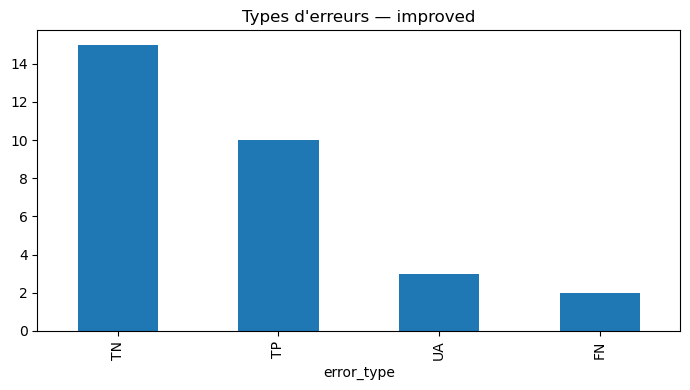

,case_id,ground_truth,prediction,confidence,comment
17,RSNA_018_suspected_opacity,suspected_opacity,normal,0.95,opacity missed and called normal
19,RSNA_020_suspected_opacity,suspected_opacity,normal,0.70,opacity missed and called normal


In [5]:
# Registre d'erreurs (improved) : répartition des types
reg_csv = ROOT / 'eval' / 'error_register.csv'
if reg_csv.exists():
    reg = pd.read_csv(reg_csv)
    reg['error_type'].value_counts().plot.bar(figsize=(7, 4), title="Types d'erreurs: improved")
    plt.tight_layout(); plt.show()
    display(reg[reg['error_type'] == 'FN'][['case_id', 'ground_truth', 'prediction', 'confidence', 'comment']])
else:
    print("eval/error_register.csv absent: générez-le avec :")
    print("python eval/error_register.py --predictions eval/results/improved_predictions.csv")

## Lecture

Le prompt *improved* augmente la **spécificité** (moins de faux positifs) et le taux d'abstention `uncertain`, au prix d'une **sensibilité** plus faible. C'est un arbitrage de prudence à défendre explicitement, pas à masquer. Détail complet dans `docs/rapport.md`.